In [1]:
import pyxdf    # 1.17.0'
import pandas as pd    # 2.2.3
import numpy as np    #  2.26
import matplotlib.pyplot as plt    #3.10.1
from glob import glob
import librosa    # 0.11.0
from tqdm import tqdm
import sounddevice as sd    #0.5.2
from scipy.io import wavfile
from scipy.signal import resample, correlate



subject = 'P5943825'
xdf_path = f'/Users/bryan.gonzalez/CUNY_subs/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'

### Create the Stimulus Marker DataFrame

In [2]:
stim_data, _ = pyxdf.load_xdf(xdf_path, select_streams=[{'name': 'Stimuli_Markers'}], verbose = False)
stim_df = pd.DataFrame(stim_data[0]['time_series'])
stim_df.rename(columns={0: 'trigger'}, inplace=True)
events = {
    200: 'Onset_Experiment',
    10: 'Onset_RestingState',
    11: 'Offset_RestingState',
    500: 'Onset_StoryListening',
    501: 'Offset_StoryListening',
    100: 'Onset_10second_rest',
    101: 'Offset_10second_rest', 
    20: 'Onset_CampFriend',
    21: 'Offset_CampFriend',
    30: 'Onset_FrogDissection',
    31: 'Offset_FrogDissection',
    40: 'Onset_DanceContest',
    41: 'Offset_DanceContest',
    50: 'Onset_ZoomClass',
    51: 'Offset_ZoomClass',
    60: 'Onset_Tornado',
    61: 'Offset_Tornado',
    70: 'Onset_BirthdayParty',
    71: 'Offset_BirthdayParty',
    300: 'Onset_subjectInput',
    301: 'Offset_subjectInput',
    302: 'Onset_FavoriteStory',
    303: 'Offset_FavoriteStory',
    304: 'Onset_WorstStory',
    305: 'Offset_WorstStory',
    400: 'Onset_impedanceCheck',
    401: 'Offset_impedanceCheck',
    80: 'Onset_SocialTask',
    81: 'Offset_SocialTask',
    201: 'Offset_Experiment',
}

story_onsets = [20, 30, 40, 50, 60, 70]

# relabel the event if the trigger is in the events dictionary, else label it as 'Bx_input' 
stim_df['event'] = stim_df['trigger'].apply(lambda x: events[x] if x in events.keys() else 'Bx_input')

# relabel the event as a psychopy timestamp if the trigger is greater than 5 digits
stim_df.loc[stim_df.trigger.astype(str).str.len() > 5, 'event'] = 'psychopy_time_stamp'
stim_df['lsl_time_stamp'] = stim_data[0]['time_stamps']


### Import the microphone stream and trim to story listening portion

In [3]:
mic_data, _ = pyxdf.load_xdf(xdf_path, select_streams=[{'name': 'Microphone'}], verbose = False)
mic_df = pd.DataFrame(mic_data[0]['time_series'], columns=['int_array'])
mic_df['lsl_time_stamp'] = mic_data[0]['time_stamps']

# Reduce the mic_data to only the story listening events, we have triggers for onset and offset of the story listening block
mic_df = mic_df.loc[(mic_df.lsl_time_stamp >= stim_df.loc[stim_df.event == 'Onset_StoryListening', 'lsl_time_stamp'].values[0]) & 
                  (mic_df.lsl_time_stamp <= stim_df.loc[stim_df.event == 'Offset_StoryListening', 'lsl_time_stamp'].values[0])]

mic = mic_df['int_array'].values

### Import the behavior file from psychopy to get stimulus order

In [4]:
psycho = pd.read_csv(f'/Users/bryan.gonzalez/CUNY_subs/sub-{subject}/sub-{subject}_task-CUNY_run-001_behavior.csv', sep=',', header=0)
audio_order = [f.split('/')[-1].split('.')[0] for f in psycho.AudioFile.unique() if pd.notna(f)]

### Loop to add triggers to stimulus df

In [6]:
story_triggers = []
for story in audio_order:
    # import the audio file and downsample to 44.1kHz
    audio_file_path = '../../NEW_AUDIO_48/'+ story + '.wav'
    fs_audiofile, audiofile = wavfile.read(audio_file_path)
    audio_duration = len(audiofile) / fs_audiofile
    audiofile = resample(audiofile, int(audio_duration * 44100))

    # cross correlate with the microphone data
    corr = correlate(mic, audiofile, mode='full')
    best_index = np.argmax(corr)
    onset = best_index - len(audiofile) + 1
    onset_timestamp = mic_df.lsl_time_stamp[onset]
    story_triggers.append(onset_timestamp)

    # calculate the offset from the length of the audio file
    offset = onset + len(audiofile)
    offset_timestamp = mic_df.lsl_time_stamp[offset]
    story_triggers.append(offset_timestamp)

    # add to stim_df
    if story == 'Camp_Lose_A_Friend':
            event_id = 20
    elif story == 'Frog_Dissection_Disaster':
        event_id = 30
    elif story == 'I_Decided_To_Be_Myself_And_Won_A_Dance_Contest':
        event_id = 40
    elif story == 'I_Fully_Embarrassed_Myself_In_Zoom_Class1':
        event_id = 50
    elif story == 'Left_Home_Alone_in_a_Tornado':
        event_id = 60
    elif story == 'The_Birthday_Party_Prank':
        event_id = 70

    # Add the story onset to the stim_df
    stim_df.loc[len(stim_df)] = [event_id, f'{events[event_id]}', onset_timestamp]
    # Add the story offset to the stim_df
    stim_df.loc[len(stim_df)] = [event_id + 1, f'{events[event_id+1]}', offset_timestamp]


#sort by the lsl_time_stamp
stim_df.sort_values('lsl_time_stamp')

,trigger,event,lsl_time_stamp
0,2.000000e+02,Onset_Experiment,12249.952149
1,1.744057e+09,psychopy_time_stamp,12249.952161
2,1.000000e+01,Onset_RestingState,12260.380544
3,1.744057e+09,psychopy_time_stamp,12260.380554
4,1.100000e+01,Offset_RestingState,12560.378175
...,...,...,...
230,1.744059e+09,psychopy_time_stamp,14290.831409
231,8.100000e+01,Offset_SocialTask,14591.371014
232,1.744060e+09,psychopy_time_stamp,14591.371027
233,2.010000e+02,Offset_Experiment,14596.362209


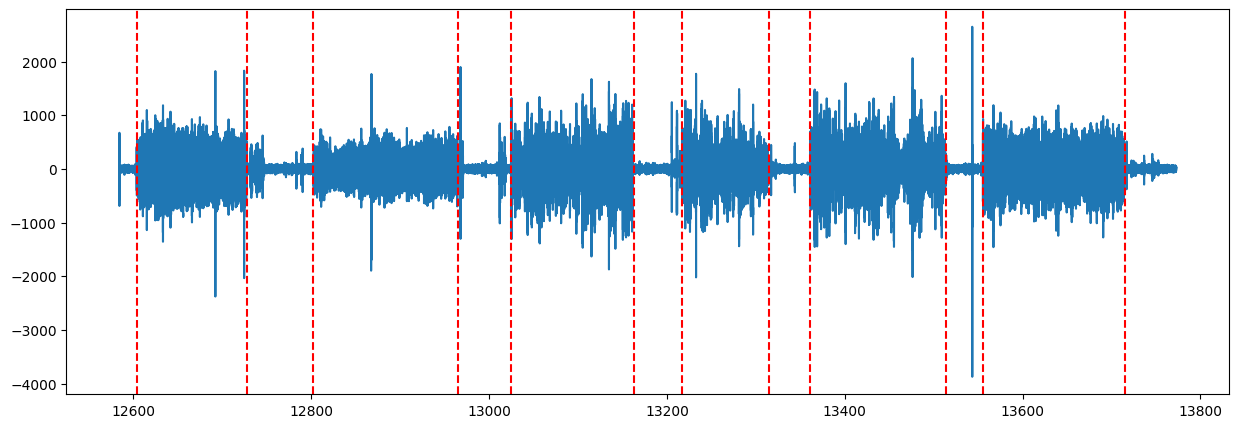

In [8]:
# change figsize

plt.figure(figsize=(15, 5))
plt.plot(mic_df.lsl_time_stamp, mic_df.int_array)
# add a vertical line for each story trigger
for trigger in story_triggers:
    plt.axvline(x=trigger, color='r', linestyle='--')

In [9]:
# Reduce the mic_data to only the story listening events, we have triggers for onset and offset of the story listening block
story_df = mic_df.loc[(mic_df.lsl_time_stamp >= stim_df.loc[stim_df.event == 'Onset_FrogDissection', 'lsl_time_stamp'].values[0]) & 
                  (mic_df.lsl_time_stamp <= stim_df.loc[stim_df.event == 'Offset_FrogDissection', 'lsl_time_stamp'].values[0])]

sd.play(story_df.int_array.values, samplerate=44100)
